# Re-Deriving the Branching Ratio 
...of eta -> mu+ mu- gamma, from the 1980 analysis paper  


**Author**: Michael Peters  

### Define constants and data

In [17]:
import numpy as np
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from tabulate import tabulate
import math

# Alternate constants (from pdg)
ALPHA = 1. / 137. # m_Z mass scale
M_ETA_PDG = 0.547862  # GeV/c^2
M_ETA = .54867  # digitized from paper
M_MU = .1056583745  # from pdg
BR_ETA2GG =.3941  # from pdg
prefactor = (2 * ALPHA) / (3 * np.pi) * BR_ETA2GG

In [18]:
# Digitized data from plot in paper
x = np.array([0.04994, 0.06962, 0.08918, 0.10887, 0.12889, 0.14895, 0.16888,
              0.18911, 0.2188])
y = np.array([1.13117, 0.96908, 1.30802, 1.54427, 1.91811, 1.82588, 1.60247,
              3.21721, 2.55531])
ybar = [1.34043, 1.13093, 1.57283, 1.71686, 2.14894, 2.08674, 1.89034, 3.86088,
        3.23895]  # upper error bars
yerr = np.subtract(ybar, y)  # y errors

# Parameters from paper
LAMBDA0 = [.72, .09]  # from paper; [value, uncertainty]
# K is a nuisance parameter that is only used to fit a value of Lambda to the data.
# Once Lambda is fit, K does not go into the integral which calculates the BR.
K0 = .9089376019880376  # digitized from Fig. 2; [value]



### Define FormFactor class

In [19]:
# TODO: make extra sure integrand and integration is correct
class FormFactor:
    def __init__(self, alpha=ALPHA, m_eta=M_ETA, m_mu=M_MU, br_eta2gg=BR_ETA2GG, Lambda0=LAMBDA0, K0=K0):
        self.alpha = alpha
        self.m_eta = m_eta
        self.m_mu = m_mu
        self.br_eta2gg = br_eta2gg
        self.q2_min = (2 * self.m_mu)**2
        self.q2_max = self.m_eta**2
        self.prefactor = (2 * self.alpha) / (3 * np.pi) * self.br_eta2gg
        self.Lambda0 = Lambda0
        self.K0 = K0
    

    # =============================================================================


    def F(self, x, Lambda, K):
        """Form factor of the eta meson in the pole approximation. Eqn. 5 from the
        paper.

        Args:
        x (param, float) : m^2_{mu,mu}
        K (float) : coefficient accounting for experimental normalization
                    uncertainty
        Lambda (float) : pole approximation coefficient

        Returns:
        Form factor F(m^2_{mu,mu}; 0)
        """
        return K * (1.0 - x / Lambda**2)**(-1)


    # =============================================================================


    def F2(self, x, Lambda, K):
        """Form factor squared of the eta meson. Eqn. from Fig. 2 caption.

        Args:
        x (param, float) : m^2_{mu,mu}
        K (float) : coefficient accounting for experimental normalization
                    uncertainty.
        Lambda (float) : pole approximation coefficient

        Returns:
        Form factor F(m^2_{mu,mu}; 0)
        """
        return K * (1.0 - x / (Lambda**2))**(-2)


    # =============================================================================


    def fit(self, x, y, yerr=None, fit_Lambda=True, fit_K=True):
        """Fit wrapper for scipy's curve_fit() which allows for choice of free
        parameters.

        Args:
            x (list): x values from data in plot
            y (list): y values from data in plot
            yerr (np.array, optional): y error values from data in plot. Defaults 
                to None.
            fit_Lambda (bool, optional): _description_. Defaults to True.
            fit_K (bool, optional): _description_. Defaults to True.

        Returns:
            dict (string, float): Lambda and K fit results, including errors.
        """
        # For all fixed values.
        if not fit_Lambda and not fit_K:
            return {'Lambda': self.Lambda0[0], 
                    'Lambda_err': self.Lambda0[1],
                    'K': K0, 
                    'K_err': 0.0}
        if fit_Lambda and fit_K:
            def fnc(x, Lambda, K): return self.F2(x, Lambda, K)
            bounds = ([0.0, 0.0], [np.inf, np.inf])
        elif fit_Lambda and not fit_K:
            def fnc(x, Lambda): return self.F2(x, Lambda, K0)
            bounds = ([0.0], [np.inf])
        elif not fit_Lambda and fit_K:
            def fnc(x, K): return self.F2(x, self.Lambda0[0], K)
            bounds = ([0.0], [np.inf])

        # Ensure all data is numpy array
        popt, pcov = curve_fit(fnc, np.array(x), np.array(y), sigma=np.array(yerr), 
                               absolute_sigma=True)
        perr = np.sqrt(np.diag(pcov))

        # Convert to float values
        popt = [float(v) for v in popt]
        perr = [float(v) for v in perr]

        result = {}
        idx = 0
        if fit_Lambda:
            result['Lambda'] = popt[idx]
            result['Lambda_err'] = perr[idx]
            idx += 1
        else:
            result['Lambda'] = self.Lambda0[0]
            result['Lambda_err'] = self.Lambda0[1]
        if fit_K:
            result['K'] = popt[idx]
            result['K_err'] = perr[idx]
            idx += 1
        else:
            result['K'] = K0
            result['K_err'] = 0.0

        return result
    

    # =============================================================================


    def integrand(self, q2, Lambda):
        """Integrand of the eta form factor integral over q2. Eqn. 4 from the
        paper.

        Args:
        q2 (param, float): m^2_{mu,mu}
        Lambda (float): pole approximation coefficient

        Returns:
        float: integrand of the eta form factor integral over q2
        """
        # Kinematic limits
        if q2 < self.q2_min or q2 > self.q2_max:
            return 0.0

        term1 = (1 - q2 / self.m_eta**2)**3
        term2 = (1 + 2 * self.m_mu**2 / q2)
        term3 = np.sqrt(1 - 4 * self.m_mu**2 / q2)
        term4 = abs(self.F2(q2, Lambda, K=1.0))
        return term1 * term2 * term3 * term4 / q2
    

    # =============================================================================


    def integrate(self, Lambda, bounds=None):
        """Calculate form factor integral.

        Args:
        Lambda (float): Parameter value
        bounds (list (float, float)): (Optional) Custom bounds of integration.
            Default bounds of integration are [self.q2_min, self.q2_max].

        Returns: 
        (float, float): integral value and its numerical uncertainty
        """
        if bounds is None: bounds = [self.q2_min, self.q2_max]

        # Pass points of possible divergence into `quad`, which then handles any
        # difficulties in convergence.
        points = []
        if bounds[0] < Lambda**2 < bounds[1]: points.append(Lambda**2)

        return integrate.quad(lambda q2: self.integrand(q2, Lambda),
                              bounds[0], bounds[1], points=points)
        # return integrate.quad(lambda q2: self.integrand(q2, Lambda),
        #                       bounds[0], bounds[1])
    

    # =============================================================================


    def branching_ratio(self, Lambda, bounds=None):
        """Calculate the branching ratio.

        Args:
            Lambda (float): Lambda parameter value

        Returns:
            list (float, float): List of branching ratio and its uncertainty value
        """
        int_val, _ = self.integrate(Lambda, bounds=bounds)
        return self.prefactor * int_val


In [20]:
# ff = FormFactor(alpha=alpha_mz, m_eta=m_eta_pdg)
ff = FormFactor()

In [21]:
fits = []
fit_Lambda = [True, False]
fit_K = [True, False]
table = []

for i in range(2):
    for j in range(2):
        fit = {'fit_Lambda': fit_Lambda[i], 'fit_K': fit_K[j]}
        fit.update(ff.fit(x, y, yerr, fit_Lambda=fit_Lambda[i], fit_K=fit_K[j]))
        fits.append(fit)

for fit in fits:
    table.append((fit['fit_Lambda'], fit['fit_K'], 
                  f"{fit['Lambda']:.2f}", f"{fit['Lambda_err']:.2f}", 
                  f"{fit['K']:.2f}", f"{fit['K_err']:.2f}"))

headers = ['fit Λ', 'fit K', 'Λ', 'ΔΛ', 'K', 'ΔK']
print(tabulate(table, headers, tablefmt="github"))

| fit Λ   | fit K   |    Λ |   ΔΛ |    K |   ΔK |
|---------|---------|------|------|------|------|
| True    | True    | 0.7  | 0.05 | 0.87 | 0.11 |
| True    | False   | 0.72 | 0.03 | 0.91 | 0    |
| False   | True    | 0.72 | 0.09 | 0.9  | 0.05 |
| False   | False   | 0.72 | 0.09 | 0.91 | 0    |


In [22]:
table = []
for fit in fits:
    int_val, int_err = ff.integrate(fit['Lambda'])
    br = ff.branching_ratio(fit['Lambda'])

    print(f"fit Lambda = {fit['fit_Lambda']}, fit K = {fit['fit_K']}:")
    print(f"integral = {int_val:.3f} ± {int_err:.0e}")
    print(f"BR = {br * 1e4:.2f}e-4\n")

    table.append((
        str(fit['fit_Lambda']),
        str(fit['fit_K']),
        f"{br * 1e4:.2f}e-4"
    ))

headers = ['fit Λ', 'fit K', 'BR']
print(tabulate(table, headers, tablefmt="github"))

fit Lambda = True, fit K = True:
integral = 0.550 ± 7e-09
BR = 3.36e-4

fit Lambda = True, fit K = False:
integral = 0.535 ± 7e-09
BR = 3.27e-4

fit Lambda = False, fit K = True:
integral = 0.534 ± 7e-09
BR = 3.26e-4

fit Lambda = False, fit K = False:
integral = 0.534 ± 7e-09
BR = 3.26e-4

| fit Λ   | fit K   |       BR |
|---------|---------|----------|
| True    | True    | 0.000336 |
| True    | False   | 0.000327 |
| False   | True    | 0.000326 |
| False   | False   | 0.000326 |


### Plot Fits

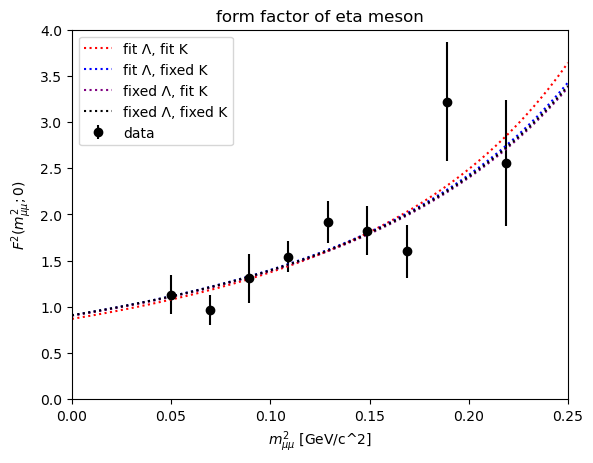

In [23]:
# Plot data with error bars and the fitted curve
plt.errorbar(x, y, yerr=yerr, fmt='o', color='black', label='data')
xx = np.linspace(0, 0.25, 400)
plt.plot(xx, ff.F2(xx, fits[0]['Lambda'], fits[0]['K']), ':', color='red',
            label=f"fit Λ, fit K")
plt.plot(xx, ff.F2(xx, fits[1]['Lambda'], fits[1]['K']), ':', color='blue',
            label=f"fit Λ, fixed K")
plt.plot(xx, ff.F2(xx, fits[2]['Lambda'], fits[2]['K']), ':', color='purple',
            label=f"fixed Λ, fit K")
plt.plot(xx, ff.F2(xx, fits[3]['Lambda'], fits[3]['K']), ':', color='black',
            label=f"fixed Λ, fixed K")
plt.legend()
plt.xlim(0, .25)
plt.ylim(0, 4)
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV/c^2]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")
plt.title("form factor of eta meson")
plt.show()


These fits are all in very close agreement, deviating most significantly at the tail end (which is expected given the greater variance and fewer data points).

## Uncertainty Propagation

### Method I: Numerical Propagation

Here, we sample `n` values of Λ normally distributed about its mean, with standard deviation $\sigma_\Lambda$.

For each Λ sampled, we compute the branching ratio. We then collect all these branching ratio values and find their mean and standard deviation.

In [24]:
ff = FormFactor()
n = 10000
Lambdas = np.random.normal(LAMBDA0[0], LAMBDA0[1], n)

br_values = []
for Lambda in Lambdas:
    int_val, int_err = ff.integrate(Lambda)
    br = ff.branching_ratio(Lambda)
    br_values.append(br)

br_values = np.array(br_values)
br_mean = np.mean(br_values)
br_unc  = math.sqrt(np.std(br_values)**2 + int_err**2)
print(f"BR = ({br_mean * 10000.:.2f} ± {br_unc * 10000.:.2f})e-4")

/var/folders/vx/cy_c9gk53x7b6f1k5brcs4r40000gn/T/ipykernel_76677/1995652674.py:161: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return integrate.quad(lambda q2: self.integrand(q2, Lambda),


BR = (3.42 ± 0.63)e-4


The result is in agreement with previous calculations (somewhat too high).

---

### Method II: $\pm\sigma$ Difference
Calculate branching ratio from $\Lambda+\sigma_\Lambda$ and $\Lambda-\sigma_\Lambda$, find the difference, then divide by 2. This method is quick and works well if the lambda uncertainty is smooth and approximately linear.

In [25]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)

br_p = ff_p.branching_ratio(Lambda_p)
br_m = ff_m.branching_ratio(Lambda_m)

# Print values
print(f"BR+ = {br_p * 10000.:.2f}e-4")
print(f"BR- = {br_m * 10000.:.2f}e-4\n")

# Find difference
br_unc = abs((br_p - br_m)) / 2.
print(f"BR uncertainty = {br_unc * 10000.:.2f}e-4\n")

BR+ = 2.96e-4
BR- = 3.83e-4

BR uncertainty = 0.43e-4



Phil also mentioned a slightly different method of doing this. I'll try it just to see if there's any difference.

In [26]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)
ff = FormFactor(Lambda0=LAMBDA0[0])

br_unc_p = ff_p.branching_ratio(Lambda_p) - ff.branching_ratio(LAMBDA0[0])
br_unc_m = ff.branching_ratio(LAMBDA0[0]) - ff_m.branching_ratio(Lambda_m)

# Print values
print(f"ΔBR+ = {br_unc_p * 10000.:.2f}e-4")
print(f"ΔBR- = {br_unc_m * 10000.:.2f}e-4\n")

# Find average
br_unc = abs((br_unc_p + br_unc_m)) / 2.
print(f"BR uncertainty = {br_unc * 10000.:.2f}e-4\n")

ΔBR+ = -0.30e-4
ΔBR- = -0.57e-4

BR uncertainty = 0.43e-4



The end result is the same.

## Reconstructing Paper

Best coord: (m_eta=0.540127, alpha=0.007324, chi2=4.96e-06)
BR at best: 3.0994e-04 (target 3.10e-04)
dBR at best: 3.9932e-05 (target 4e-05)


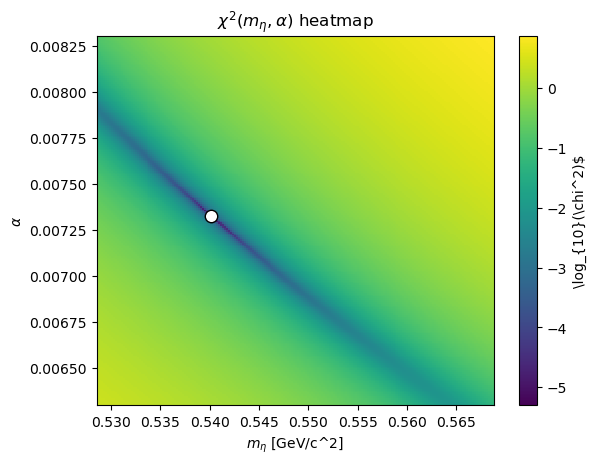

In [27]:
# TODO: check branching fraction value
# Find best m_eta and alpha values using system of two equations (BR and dBR)
# Perform a grid scan to minimize chi2, plot on colormap

# Target values from paper
BR0, DBR0 = 3.1e-4, 0.4e-4

# Define Lambda values
Lambda0, dLambda0 = LAMBDA0
Lambda_p = Lambda0 + dLambda0
Lambda_m = Lambda0 - dLambda0

# Define eta mass range to search
# m_eta_vals = np.linspace(0.535, 0.555, 161)
# alpha_vals = np.linspace(0.0066, 0.0078, 161)
m_eta_vals = np.linspace(M_ETA-0.02, M_ETA+0.02, 200)
alpha_vals = np.linspace(ALPHA-0.001, ALPHA+0.001, 200)

# Compute BR and deltaBR over grid of m_eta and alpha values
# Create numpy arrays to hold results 
I_o = np.zeros(m_eta_vals.shape, dtype=float)
I_p = np.zeros(m_eta_vals.shape, dtype=float)
I_m = np.zeros(m_eta_vals.shape, dtype=float)

# Calculate integrals (use full q^2 range)
for i, m_eta in enumerate(m_eta_vals):
    ff = FormFactor(m_eta=m_eta)
    try:
        I_o[i], _ = ff.integrate(Lambda0)
        I_p[i], _ = ff.integrate(Lambda_p)
        I_m[i], _ = ff.integrate(Lambda_m)
    except Exception: continue

# Calculate prefactor values
prefactor_vals = (2.0 * alpha_vals) / (3.0 * np.pi) * BR_ETA2GG

# Calculate BR and dBR values
BR_vals = np.outer(prefactor_vals, I_o)
dBR_vals = np.outer(prefactor_vals, np.abs((I_p - I_m))) / 2.0

# Calculate chi2 values
chi2_vals = ((BR_vals - BR0) / DBR0)**2 + ((dBR_vals - DBR0) / DBR0)**2
# Find minimum chi2 value and corresponding m_eta and alpha
# To understand unravel_index(): numpy arrays are stored in a 1d format. argmin
# returns the minimum value's 1d index. unravel_index interprets what that value
# is in the original shape of the array.
best_idx = np.unravel_index(np.argmin(chi2_vals), chi2_vals.shape)
best_alpha = alpha_vals[best_idx[0]]
best_m_eta = m_eta_vals[best_idx[1]]
best_chi2 = chi2_vals[best_idx]

print(f'Best coord: (m_eta={best_m_eta:.6f}, alpha={best_alpha:.6f}, chi2={best_chi2:.2e})')
print(f'BR at best: {BR_vals[best_idx]:.4e} (target {BR0:.2e})')
print(f'dBR at best: {dBR_vals[best_idx]:.4e} (target {DBR0:.0e})')

# Plot chi2 as 2d heatmap
def plot_chi2(x, y, z, log_scale=True):
    """
    Helper function to plot data with associated colormap.
    """
    fig, ax = plt.subplots()
    
    if log_scale: z = np.log10(z)
    c = ax.pcolormesh(x, y, z, shading="auto")
    fig.colorbar(c, ax=ax, label=r'\log_{10}(\chi^2)$')
    
    ax.scatter([best_m_eta], [best_alpha], c='white', edgecolors='black', s=80)
    ax.set_xlabel(r'$m_\eta$ [GeV/c^2]')
    ax.set_ylabel(r'$\alpha$')
    ax.set_title(r'$\chi^2(m_\eta, \alpha)$ heatmap')

    plt.show()

plot_chi2(m_eta_vals, alpha_vals, chi2_vals)

# TODO: Listen to the voice recording from the 23 January meeting with Phil.
# It's very important, especially the middle and end discussions.

### Plot of (br uncertainty / br) vs q2 max

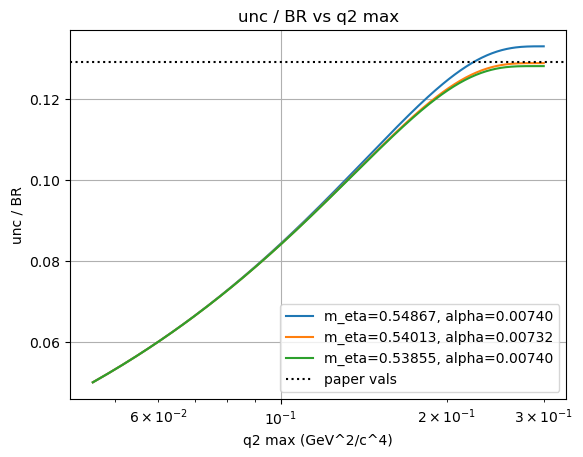

In [32]:
# TODO: Use uncertainty value method from above
# Target values from paper
BR0, DBR0 = 3.1e-4, 0.4e-4

# Define Lambda values
Lambda0, dLambda0 = LAMBDA0
Lambda_p = Lambda0 + dLambda0
Lambda_m = Lambda0 - dLambda0

# Plot (uncertainty / br) vs q2 max for fixed m_eta, fixed alpha; fixed m_eta, fit alpha; fit m_eta, fixed alpha
# q2 max values from .210 to .54867
# q2_max_values = np.arange(0.210, 0.54867, 0.001)
q2_max_values = np.arange((2 * M_MU) ** 2, 0.3, 0.001)
# Define m_eta and alpha to use for looping
pairs = [[.54867, .0074], [.540127, .007324], [.53855, .0074]]  # skip fit, fit case

for pair in pairs:
    m_eta, alpha = pair
    values = [] # [q2_max, br_unc / br_val, br_val, br_unc]
    ff_temp = FormFactor(m_eta=m_eta, alpha=alpha)
    prefactor = ff_temp.prefactor

    # Sample over q2 max values and calculate br_unc / br
    for q2_max in q2_max_values:
        # Skip invalid q2 max values
        if q2_max <= ff_temp.q2_min: continue
        bounds = [ff_temp.q2_min, q2_max]

        I_o, _ = ff_temp.integrate(Lambda0, bounds=bounds)
        I_p, _ = ff_temp.integrate(Lambda_p, bounds=bounds)
        I_m, _ = ff_temp.integrate(Lambda_m, bounds=bounds)
        
        br = prefactor * I_o
        dbr = prefactor * np.abs((I_p - I_m)) / 2.0
        
        # Calculate ratio; guard against invalid values
        if not np.isfinite(br) or br == 0.0: ratio = np.nan
        else: ratio = dbr / br
        # print(f'br_val = {br_val}, br_unc = {br_unc} at q2_max = {q2_max}')  # debug
        values.append([q2_max, ratio, br, dbr])

    # Create plot from values
    values = np.array(values)
    plt.plot(values[:,0], values[:,1], label=f"m_eta={m_eta:.5f}, alpha={alpha:.5f}")
    plt.legend()  # debug
    # plt.show()  # debug

# Plot actual line for reference (br = 3.1e-4, unc = 0.4e-5)
plt.axhline(DBR0 / BR0, color='black', linestyle=':', label='paper vals')
# plt.axhline(3.7e-5 / 3.1e-4, color='red', linestyle='--', label='lower unc')
# plt.yscale('log')
plt.xlabel('q2 max (GeV^2/c^4)')
plt.ylabel('unc / BR')
plt.title('unc / BR vs q2 max')
plt.grid()
plt.legend()
plt.xscale('log')
plt.show()

## Extra Cells
The $\chi^2$ fit above makes these next cells less important, but it's still an 
interesting study of what mass and alpha values would be needed based on the 
apparent/assumed values from the paper. The results are puzzling, and in any 
case demonstrates that they probably should have stated these values to make 
their branching ratio calculation verifiable.

### Deriving mass of eta used in paper
Find the mass value needed to get a branching ratio of 3.1e-4 for fixed alpha = .0074.

|    Λ |   ΔΛ |   m_eta |      BR |
|------|------|---------|---------|
| 0.72 | 0.09 |  0.5407 | 0.00031 |


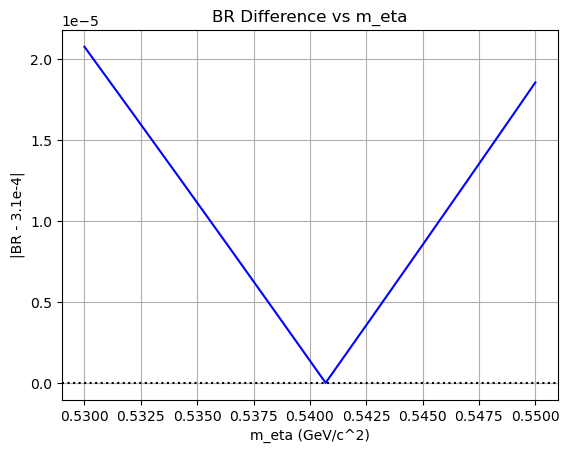

In [29]:
br_target = 3.1e-4
table = []
values = []

for m_eta in np.arange(.53, .55, .00001):
    ff_temp = FormFactor(m_eta=m_eta)
    br_temp = ff_temp.branching_ratio(LAMBDA0[0])
    diff = abs(br_temp - br_target)
    values.append((m_eta, br_temp, diff))

# Find minimum
values = np.array(values)
# : = all rows; 2 = third column (diff)
min_idx = np.argmin(values[:,2])
# min_idx = row, 0 = first column (m_eta)
m_eta_best = values[min_idx,0]
# 1 = second column (br)
br_best = values[min_idx,1]

table.append([LAMBDA0[0], LAMBDA0[1], f"{m_eta_best:.6f}", f"{br_best * 1e4:.2f}e-4"])
# Print table
headers = ['Λ', 'ΔΛ', 'm_eta', 'BR']
print(tabulate(table, headers, tablefmt="github"))

# Plot
plt.plot(values[:,0], values[:,2], color='blue', linestyle='-')
plt.axhline(0, color='black', linestyle=':')
plt.xlabel('m_eta (GeV/c^2)')
plt.ylabel('|BR - 3.1e-4|')
plt.title('BR Difference vs m_eta')
plt.grid()
plt.show()


### Deriving alpha used in paper
Finds the alpha value needed to get exactly a branching ratio of 3.1e-4 for fixed m_eta = .54867.

In [30]:
ff = FormFactor()
br0 = 3.1e-4  # target branching ratio
table = []

for fit in fits:
      int_val, int_err = ff.integrate(fit['Lambda'])
      pre = br0 / int_val
      # Extract alpha from prefactor
      alpha = (pre / 2) * (3 * np.pi) / BR_ETA2GG
      # Add to table
      table.append([fit['fit_Lambda'], fit['fit_K'], f"{alpha:.5f}"])

headers=['fit Λ', 'fit K', 'alpha']
print(tabulate(table, headers, tablefmt="github", colalign=(",","center","center")))


|   fit Λ |  fit K  |  alpha  |
|---------|---------|---------|
| True    |  True   | 0.00674 |
| True    |  False  | 0.00692 |
| False   |  True   | 0.00694 |
| False   |  False  | 0.00694 |


In [31]:
# Repeat using m_eta derived above (.53855), just to confirm alpha values
ff = FormFactor(m_eta=m_eta_best)
br0 = 3.1e-4  # target branching ratio
table = []

for fit in fits:
      int_val, int_err = ff.integrate(fit['Lambda'])
      pre = br0 / int_val
      # Extract alpha from prefactor
      alpha = (pre / 2) * (3 * np.pi) / BR_ETA2GG
      # Add to table
      table.append([fit['fit_Lambda'], fit['fit_K'], f"{alpha:.5f}"])

headers=['fit Λ', 'fit K', 'alpha']
print(tabulate(table, headers, tablefmt="github", colalign=(",","center","center")))

|   fit Λ |  fit K  |  alpha  |
|---------|---------|---------|
| True    |  True   | 0.00709 |
| True    |  False  | 0.00728 |
| False   |  True   | 0.0073  |
| False   |  False  | 0.0073  |


mu mu e e